# Project 1 — Intelligent Matching and Ranking
## 01 · Data discovery and quality

> All data here is **synthetic demo data** (`common/synthetic.py`). It reproduces the schema and structure of the marketplace's lead flow; no row is a real customer or provider.

### Analytical question
What do we know about customers, providers and historical offers, and is the data fit for modelling?

### Evidence so far
Nothing yet — this is the first look.

### Why this approach?
Validation runs *before* any analysis so that later decisions cite counted facts (duplicates, orphans, missingness), not impressions. The schema checks live in `src/data.py` and are reused by every downstream pipeline.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))
os.chdir(os.path.abspath('../..'))
import pandas as pd, numpy as np, matplotlib.pyplot as plt
pd.set_option('display.width', 160)
%matplotlib inline
from project1_matching.src import data
ins_raw, leads_raw, offers_raw = data.load('data/synthetic')
ins, leads, offers, reports = data.clean(ins_raw, leads_raw, offers_raw)
pd.concat([r.to_frame().assign(dataset=n) for n, r in reports.items()]).query('~passed')

23:26:16 p1.data INFO: providers: 224 -> 220 after de-duplication


23:26:16 p1.data INFO: leads: 3000 -> 2936 after dropping unknown zone


23:26:16 p1.data INFO: offers: 14648 -> 14645 after referential-integrity filter


,name,passed,severity,detail,dataset
18,categories:job_type,False,warning,unexpected: ['REPAIR'],providers_raw
11,referential:provider_id,False,error,3 orphan rows,offers_raw


### Result / Interpretation
Raw provider data fails the unique-key check (duplicate registrations) and has inconsistent job_type casing; the offers log has orphan provider ids. All three are the kind of thing that silently corrupts a join. After cleaning, the gates pass.

### Decision
Proceed with the cleaned frames; the de-duplication rule (exact match on stable attributes) is recorded in the decision log (D1).

(220, 16) (2936, 14) (14645, 8)


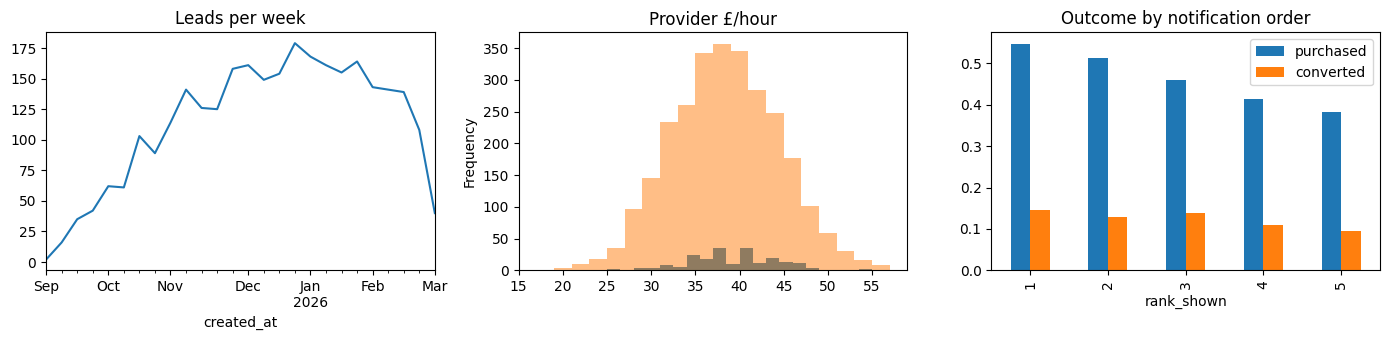

In [2]:
print(ins.shape, leads.shape, offers.shape)
fig, ax = plt.subplots(1, 3, figsize=(14, 3.5))
leads.created_at.dt.to_period('W').value_counts().sort_index().plot(ax=ax[0], title='Leads per week')
ins.price_per_hour.plot.hist(ax=ax[1], bins=20, title='Provider £/hour'); leads.budget_max.plot.hist(ax=ax[1], bins=20, alpha=.5)
offers.groupby('rank_shown')[['purchased','converted']].mean().plot.bar(ax=ax[2], title='Outcome by notification order'); plt.tight_layout()

### Interpretation
Demand grows over the window (marketing ramp). Provider prices and customer budgets overlap but not perfectly — price gap will matter. Purchase probability falls with notification order: a **position effect** is present in the logs. That has a direct consequence for how the ranker must be trained (notebook 02).

In [3]:
from project1_matching.src import candidates
cov = candidates.coverage_report(leads, ins)
cov

{'n_leads': 2936,
 'share_with_candidates': 1.0,
 'share_relaxed': 0.1055858310626703,
 'candidate_size_median': 33.0,
 'candidate_size_p10': 9.0,
 'candidate_size_p90': 61.0}

### Interpretation
Every lead has at least one eligible provider, but ~10% only after relaxing the availability filter. Candidate sets are wide (median ~35), so ranking — not eligibility — is the binding problem.

### Decision
Keep the strict → relaxed candidate policy; measure ranking within candidate sets.